# Optimal gate parameters for the binomial code: SNAP+D vs. ECD

Working notebook for the $S = 1$ binomial code

$$\ket{0_L} = \frac{\ket{0} + \ket{4}}{\sqrt 2}, \qquad \ket{1_L} = \ket{2},$$

the smallest member of the family that corrects a single photon loss. Two questions:

1. **Minimum circuit depth.** For each gate set, what is the smallest `n_gates` that reaches $F \ge F_\star$ for (a) preparing $\ket{0_L}$ from vacuum, (b) preparing $\ket{1_L}$ from vacuum, (c) the logical $X_L$ on the code subspace?
2. **Which gate set is cheaper.** Depth is not comparable across gate sets — one ECD is not one SNAP — so the comparison is made in parameter count and in peak displacement amplitude, both of which map onto hardware cost.

Gates are ideal unitaries here (no Kerr, no finite duration, no dispersive phase), so every fidelity below is an ansatz-limited upper bound on a real circuit of the same depth.

Protocol: for each (gate set, task) pair, sweep depth upward with a fixed multi-start budget and stop at the first depth clearing $F_\star$, keeping one extra depth beyond it to confirm the curve is still falling rather than plateauing at the ansatz ceiling.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import jax

jax.config.update("jax_enable_x64", True)  # before any array is created

import time

import jax.numpy as jnp
import jaxquantum as jqt
import matplotlib.pyplot as plt
import numpy as np

from gkp_optimal_control.gate_optimization import (
    GateBounds,
    OptimizerConfig,
    optimize_gate_sequence,
)
from gkp_optimal_control.plotting import (
    plot_photon_number,
    plot_wigner,
    set_plot_style,
)
from gkp_optimal_control.utils import to_ket

set_plot_style()

Run parameters in one place. `N_FOCK` only has to hold the code states up to $\ket{4}$, but the
*intermediate* states are displaced well beyond either endpoint, so the truncation is set by the
largest $|\beta|$ the optimizer is allowed rather than by $\bar n$ of the target. `N_LEAK` levels
are penalized after every displacement in the circuit.

In [2]:
N_FOCK = 40           # truncation
N_LEAK = 6            # top Fock levels carrying the leakage penalty
MAX_DISP = 3.0        # soft cap on |beta| (ECD) / |alpha| (SNAP)
N_SNAP = 12           # Fock phases optimized per SNAP gate

TARGET_F = 0.999      # depth-sweep success threshold
DISP_METHOD = "quadrature"
LOSS_TYPE = "log_infidelity"

BOUNDS = GateBounds(max_disp=MAX_DISP, n_leak=N_LEAK, leakage_weight=1.0)

# One optimizer budget for every point in the sweep, so that depth curves are
# comparable: a depth that fails here has failed at a fixed budget, not at a
# fixed effort.
OPT = OptimizerConfig(
    n_seeds=24,
    n_adam_iters=2000,
    peak_lr=0.03,
    polish=True,
    polish_maxiter=1000,
    seed=0,
)

# Longer, gentler settings for the warm-start refinement of the winning runs.
OPT_POLISH = OptimizerConfig(
    n_adam_iters=1500, peak_lr=0.004, polish=True, polish_maxiter=3000
)

## Code states

$\ket{0_L}$ and $\ket{1_L}$ are exact Fock superpositions, so they are written directly rather than
built by a lattice sum. The logical $\ket{\pm_L}$ are needed only as diagnostics.

The $S=1$ code protects against a single loss because $a\ket{0_L} \propto \ket{3}$ and
$a\ket{1_L} \propto \ket{1}$ live in disjoint, odd-photon-number sectors, while both logical states
have the same mean photon number $\bar n = 2$ — so photon loss carries no information about the
logical state at first order.

In [3]:
def binomial_code_states(n_fock: int) -> tuple[jqt.Qarray, jqt.Qarray]:
    "S = 1 binomial code words: (|0> + |4>)/sqrt(2) and |2>."
    if n_fock <= 4:
        raise ValueError(f"n_fock must exceed 4 to hold |4>; got {n_fock}")
    zero_l = jnp.zeros(n_fock, dtype=jnp.complex128).at[0].set(1.0).at[4].set(1.0)
    one_l = jnp.zeros(n_fock, dtype=jnp.complex128).at[2].set(1.0)
    return (
        jqt.Qarray.create(zero_l.reshape(-1, 1)).unit(),
        jqt.Qarray.create(one_l.reshape(-1, 1)).unit(),
    )


vac = jqt.basis(N_FOCK, 0)
bin_0, bin_1 = binomial_code_states(N_FOCK)
bin_plus = jqt.Qarray.create((to_ket(bin_0) + to_ket(bin_1)).reshape(-1, 1)).unit()
bin_minus = jqt.Qarray.create((to_ket(bin_0) - to_ket(bin_1)).reshape(-1, 1)).unit()

ns = jnp.arange(N_FOCK)
print(f"<0_L|1_L> = {float(jnp.abs(jnp.vdot(to_ket(bin_0), to_ket(bin_1)))):.2e}")
for label, state in [("|0_L>", bin_0), ("|1_L>", bin_1), ("|+_L>", bin_plus)]:
    probs = jnp.abs(to_ket(state)) ** 2
    print(
        f"{label:>7}:  n_bar = {float(jnp.sum(ns * probs)):5.2f}   "
        f"top-{N_LEAK} Fock population = {float(jnp.sum(probs[-N_LEAK:])):.2e}"
    )

<0_L|1_L> = 0.00e+00
  |0_L>:  n_bar =  2.00   top-6 Fock population = 0.00e+00
  |1_L>:  n_bar =  2.00   top-6 Fock population = 0.00e+00
  |+_L>:  n_bar =  2.00   top-6 Fock population = 0.00e+00


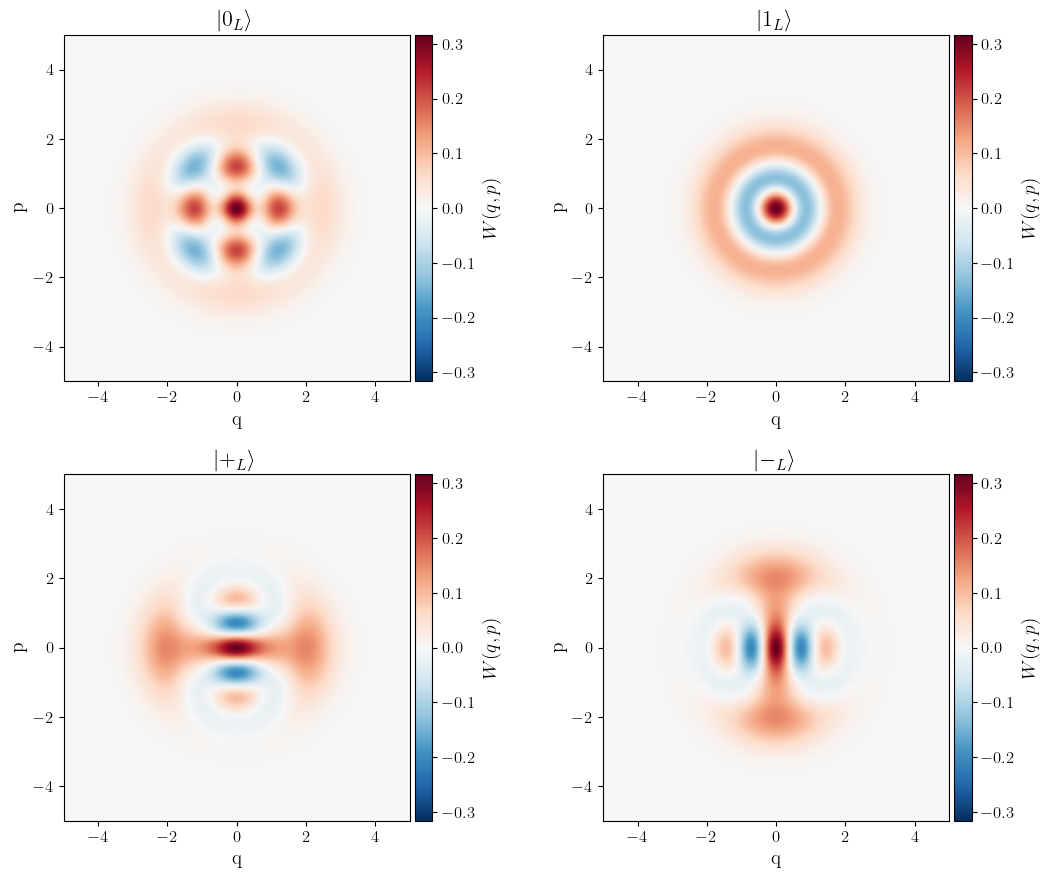

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (state, name) in zip(
    fig.axes,
    [(bin_0, r"0_L"), (bin_1, r"1_L"), (bin_plus, r"+_L"), (bin_minus, r"-_L")],
):
    plot_wigner(state, x_bound=5, y_bound=5, ax=ax, title=rf"$\ket{{{name}}}$")
fig.tight_layout()
plt.show()

## Tasks and objectives

Three optimization targets, each run against both gate sets.

| Task | Inputs | Targets | `batch_reduction` |
|---|---|---|---|
| `prep_0` | $\ket{0}$ | $\ket{0_L}$ | `"mean"` (single pair) |
| `prep_1` | $\ket{0}$ | $\ket{1_L}$ | `"mean"` (single pair) |
| `X_L` | $\ket{0_L}, \ket{1_L}$ | $\ket{1_L}, \ket{0_L}$ | `"coherent"` |

The reduction matters only for `X_L`. Averaging per-pair fidelities would let each basis state find
its own phase, so a high score would not certify a coherent gate; `"coherent"` averages the overlaps
before squaring, $F = |\overline{\braket{\psi_t|U|\psi_i}}|^2$, leaving exactly one global phase
free. The two inputs are orthonormal and span the code space, so constraining them coherently fixes
the action on the whole subspace — the $\ket{\pm_L}$ pairs would be redundant.

$X_L$ is expected to be the harder task of the three: one parameter set must satisfy two pairs at
once, and for the ECD set the ancilla must also return to $\ket{g}$ disentangled in both cases.

In [5]:
TASKS = {
    "prep_0": dict(psi_init=vac, psi_targ=bin_0, batch_reduction="mean",
                   label=r"prepare $\ket{0_L}$"),
    "prep_1": dict(psi_init=vac, psi_targ=bin_1, batch_reduction="mean",
                   label=r"prepare $\ket{1_L}$"),
    "X_L": dict(psi_init=[bin_0, bin_1], psi_targ=[bin_1, bin_0],
                batch_reduction="coherent", label=r"logical $X_L$"),
}

# Depth grids. n_gates counts ECDs or SNAPs, never total gates: the ECD ansatz
# carries n_gates + 1 rotations (4n+2 parameters), the SNAP ansatz n_gates + 1
# displacements (n*N_SNAP + 2n + 2 parameters). The grids differ because a SNAP
# gate is far more expressive per unit depth than an ECD.
DEPTHS = {
    "snap": {"prep_0": [1, 2, 3, 4, 5, 6], "prep_1": [1, 2, 3, 4, 5, 6],
             "X_L": [1, 2, 3, 4, 5, 6, 7, 8]},
    "ecd": {"prep_0": [2, 3, 4, 5, 6, 7, 8], "prep_1": [2, 3, 4, 5, 6, 7, 8],
            "X_L": [2, 3, 4, 5, 6, 7, 8, 9, 10]},
}

## Sweep driver

`run_sweep` walks a depth grid at fixed budget and stops `n_extra` depths past the first success, so
the curve always contains at least one point beyond threshold. Results are keyed
`(gate_set, task)` and each entry maps depth to a `GateOptResult`; wall time is tracked separately
since `GateOptResult` does not carry it.

In [6]:
RESULTS: dict[tuple[str, str], dict[int, object]] = {}
TIMINGS: dict[tuple[str, str], dict[int, float]] = {}


def run_sweep(gate_set, task, *, depths=None, target_f=TARGET_F, n_extra=1,
              optimizer=OPT, bounds=BOUNDS, verbose_runs=False):
    # Sweep depth for one (gate_set, task) pair, stopping n_extra past
    # threshold; populates RESULTS[(gate_set, task)] and returns that dict.
    spec = TASKS[task]
    depths = DEPTHS[gate_set][task] if depths is None else depths
    store = RESULTS.setdefault((gate_set, task), {})
    times = TIMINGS.setdefault((gate_set, task), {})

    print(f"=== {gate_set:>4} | {task:<7} | depths {depths} | target F = {target_f} ===")
    hit_at = None
    for depth in depths:
        t0 = time.perf_counter()
        from gkp_optimal_control.gate_results import gate_result_path, load_gate_result, save_gate_result
        _path = gate_result_path('data/gate_results/binomial_code_gate_params', gate_set, depth)
        if _path.exists():
            res = load_gate_result(_path)
            print("loaded cached result from " + str(_path))
        else:
            res = optimize_gate_sequence(gate_set, depth, spec['psi_init'], spec['psi_targ'], n_fock=N_FOCK, n_snap=N_SNAP if gate_set == 'snap' else None, disp_method=DISP_METHOD, loss_type=LOSS_TYPE, batch_reduction=spec['batch_reduction'], bounds=bounds, optimizer=optimizer, verbose=verbose_runs)
            save_gate_result(res, _path, initial_state=spec['psi_init'], overwrite=True, source_notebook='binomial_code_gate_params')

        elapsed = time.perf_counter() - t0
        store[depth] = res
        times[depth] = elapsed
        print(
            f"  n_gates = {depth:>2}  n_params = {res.flat_params.size:>3}  "
            f"1 - F = {1 - res.fidelity:.3e}  leak = {res.leakage:.1e}  "
            f"peak|d| = {res.params['disp_magnitudes'].max():.2f}  "
            f"({elapsed:.0f}s)"
        )
        if hit_at is None and res.fidelity >= target_f:
            hit_at = depth
            print(f"  -> threshold met at n_gates = {depth}")
        if hit_at is not None and depth >= hit_at + n_extra:
            break
    if hit_at is None:
        print("  -> threshold NOT met on this grid")
    print()
    return store


def curve(gate_set, task):
    # Sorted (depths, infidelities, n_params) arrays for one sweep.
    store = RESULTS.get((gate_set, task), {})
    depths = np.array(sorted(store))
    infid = np.array([1 - store[d].fidelity for d in depths])
    n_par = np.array([store[d].flat_params.size for d in depths])
    return depths, infid, n_par


def min_depth(gate_set, task, target_f=TARGET_F):
    # Smallest swept depth clearing target_f, or None.
    depths, infid, _ = curve(gate_set, task)
    ok = depths[infid <= 1 - target_f]
    return int(ok[0]) if ok.size else None


def best_result(gate_set, task, target_f=TARGET_F):
    # Result at min_depth if the threshold was met, else the highest-F run.
    store = RESULTS[(gate_set, task)]
    d = min_depth(gate_set, task, target_f)
    if d is None:
        d = max(store, key=lambda k: store[k].fidelity)
    return d, store[d]

## Loop 1 — SNAP + displacements

$$U = D(\alpha_{N+1}) \prod_{i=N}^{1} S(\vec\theta_i)\, D(\alpha_i), \qquad
S(\vec\theta) = \sum_n e^{i\theta_n}\ket{n}\bra{n}.$$

In [7]:
for task in TASKS:
    run_sweep("snap", task)

=== snap | prep_0  | depths [1, 2, 3, 4, 5, 6] | target F = 0.999 ===
  n_gates =  1  n_params =  16  1 - F = 1.958e-01  leak = 5.0e-27  peak|d| = 1.39  (8s)
  n_gates =  2  n_params =  30  1 - F = 1.668e-06  leak = 7.1e-18  peak|d| = 1.47  (14s)
  -> threshold met at n_gates = 2
  n_gates =  3  n_params =  44  1 - F = 9.043e-07  leak = 1.6e-12  peak|d| = 1.11  (19s)

=== snap | prep_1  | depths [1, 2, 3, 4, 5, 6] | target F = 0.999 ===
  n_gates =  1  n_params =  16  1 - F = 7.600e-02  leak = 2.8e-28  peak|d| = 1.49  (7s)
  n_gates =  2  n_params =  30  1 - F = 1.016e-06  leak = 4.3e-18  peak|d| = 1.45  (14s)
  -> threshold met at n_gates = 2
  n_gates =  3  n_params =  44  1 - F = 2.693e-07  leak = 2.8e-13  peak|d| = 1.15  (18s)

=== snap | X_L     | depths [1, 2, 3, 4, 5, 6, 7, 8] | target F = 0.999 ===
  n_gates =  1  n_params =  16  1 - F = 2.163e-01  leak = 4.5e-17  peak|d| = 0.97  (8s)
  n_gates =  2  n_params =  30  1 - F = 1.634e-02  leak = 4.3e-14  peak|d| = 1.28  (14s)
  n_g

## Loop 2 — ECD + qubit rotations

$$U = R(\theta_{N+1},\phi_{N+1}) \prod_{i=N}^{1} \mathrm{ECD}(\beta_i)\, R(\theta_i,\phi_i),
\qquad \mathrm{ECD}(\beta) = D(\beta/2)\ket{e}\bra{g} + D(-\beta/2)\ket{g}\bra{e}.$$

In [8]:
for task in TASKS:
    run_sweep("ecd", task)

===  ecd | prep_0  | depths [2, 3, 4, 5, 6, 7, 8] | target F = 0.999 ===
  n_gates =  2  n_params =  10  1 - F = 3.911e-01  leak = 2.0e-22  peak|d| = 1.91  (11s)
  n_gates =  3  n_params =  14  1 - F = 2.030e-01  leak = 6.0e-27  peak|d| = 1.93  (17s)
  n_gates =  4  n_params =  18  1 - F = 5.312e-02  leak = 1.0e-19  peak|d| = 2.13  (21s)
  n_gates =  5  n_params =  22  1 - F = 8.308e-03  leak = 9.9e-14  peak|d| = 2.04  (25s)
  n_gates =  6  n_params =  26  1 - F = 2.008e-03  leak = 1.8e-10  peak|d| = 2.06  (30s)
  n_gates =  7  n_params =  30  1 - F = 3.232e-05  leak = 3.2e-16  peak|d| = 1.56  (35s)
  -> threshold met at n_gates = 7
  n_gates =  8  n_params =  34  1 - F = 6.731e-05  leak = 3.3e-11  peak|d| = 2.62  (41s)

===  ecd | prep_1  | depths [2, 3, 4, 5, 6, 7, 8] | target F = 0.999 ===
  n_gates =  2  n_params =  10  1 - F = 4.587e-01  leak = 1.6e-29  peak|d| = 2.19  (12s)
  n_gates =  3  n_params =  14  1 - F = 7.134e-02  leak = 3.1e-27  peak|d| = 1.97  (16s)
  n_gates =  4  n_

## Depth curves

Panels share axes so the two gate sets can be read against each other per task. The threshold line
is $1 - F_\star$. A curve that flattens well above it has hit the ansatz ceiling and needs depth,
not seeds; a curve still falling at the last point is budget-limited and worth extending.

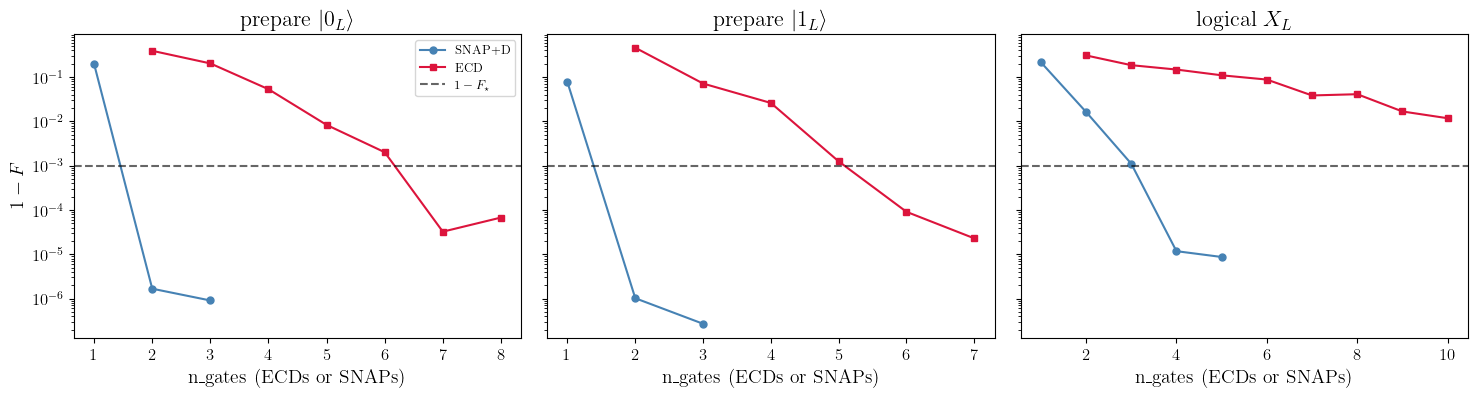

In [9]:
STYLE = {
    "snap": dict(color="steelblue", marker="o", label="SNAP+D"),
    "ecd": dict(color="crimson", marker="s", label="ECD"),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (task, spec) in zip(axes, TASKS.items()):
    for gate_set in ("snap", "ecd"):
        depths, infid, _ = curve(gate_set, task)
        if depths.size:
            ax.plot(depths, infid, linewidth=1.5, markersize=5, **STYLE[gate_set])
    ax.axhline(1 - TARGET_F, color="black", linestyle="--", alpha=0.6,
               label=rf"$1 - F_\star$")
    ax.set_yscale("log")
    ax.set_xlabel("n_gates (ECDs or SNAPs)")
    ax.set_title(spec["label"])
axes[0].set_ylabel(r"$1 - F$")
axes[0].legend(fontsize=9)
fig.tight_layout()
plt.show()

Same data against parameter count, which is the gate-set-agnostic axis: depth counts different
objects in the two ansaetze, but a parameter is a number a pulse compiler has to calibrate either
way.

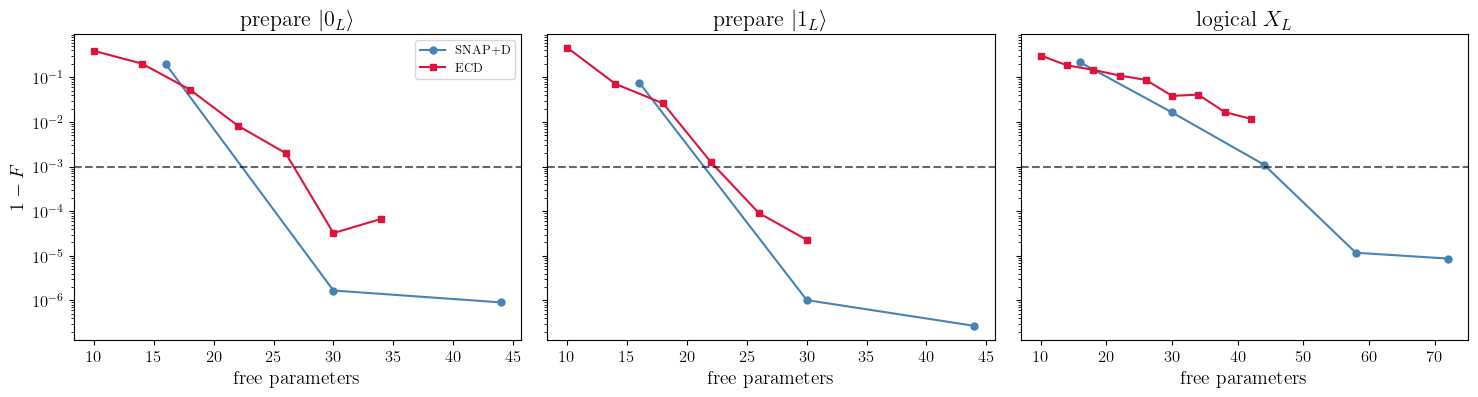

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (task, spec) in zip(axes, TASKS.items()):
    for gate_set in ("snap", "ecd"):
        depths, infid, n_par = curve(gate_set, task)
        if depths.size:
            ax.plot(n_par, infid, linewidth=1.5, markersize=5, **STYLE[gate_set])
    ax.axhline(1 - TARGET_F, color="black", linestyle="--", alpha=0.6)
    ax.set_yscale("log")
    ax.set_xlabel("free parameters")
    ax.set_title(spec["label"])
axes[0].set_ylabel(r"$1 - F$")
axes[0].legend(fontsize=9)
fig.tight_layout()
plt.show()

## Resource table

The headline result: minimum depth clearing $F_\star$, and what that circuit costs in parameters,
peak displacement amplitude and leakage. `peak |d|` is the number to check against hardware for the
ECD set, since the required amplitude sets the gate duration.

In [11]:
header = (
    f"{'task':<8} {'set':<5} {'depth':>5} {'params':>6} {'1-F':>10} "
    f"{'peak|d|':>8} {'leak':>9} {'seed spread':>22} {'time/run':>9}"
)
print(header)
print("-" * len(header))
for task in TASKS:
    for gate_set in ("snap", "ecd"):
        if (gate_set, task) not in RESULTS:
            continue
        d, res = best_result(gate_set, task)
        met = min_depth(gate_set, task) is not None
        spread = (
            f"{res.per_seed_fidelity.min():.4f}..{res.per_seed_fidelity.max():.4f}"
        )
        print(
            f"{task:<8} {gate_set:<5} "
            f"{str(d) + ('' if met else '*'):>5} "
            f"{res.flat_params.size:>6} {1 - res.fidelity:>10.2e} "
            f"{res.params['disp_magnitudes'].max():>8.2f} {res.leakage:>9.1e} "
            f"{spread:>22} {TIMINGS[(gate_set, task)][d]:>8.0f}s"
        )
print("\nDepths marked * did not reach the threshold on the swept grid; "
      "the row shows the best depth tried.")

task     set   depth params        1-F  peak|d|      leak            seed spread  time/run
------------------------------------------------------------------------------------------
prep_0   snap      2     30   1.67e-06     1.47   7.1e-18         0.9929..1.0000       14s
prep_0   ecd       7     30   3.23e-05     1.56   3.2e-16         0.9673..0.9998       35s
prep_1   snap      2     30   1.02e-06     1.45   4.3e-18         0.9590..1.0000       14s
prep_1   ecd       6     26   9.07e-05     1.53   7.2e-26         0.9012..0.9999       30s
X_L      snap      4     58   1.17e-05     1.13   4.4e-12         0.9811..1.0000       24s
X_L      ecd     10*     42   1.18e-02     3.05   5.2e-05         0.9056..0.9879       56s

Depths marked * did not reach the threshold on the swept grid; the row shows the best depth tried.


## Refining the winning circuits

Each minimum-depth solution is warm-started once with a long, low-learning-rate run plus an extended
L-BFGS-B polish. This separates *ansatz* capacity from *optimizer* convergence: if a depth that
missed the threshold clears it after refinement, the sweep budget was the binding constraint and the
depth curves above are pessimistic.

In [12]:
REFINED: dict[tuple[str, str], object] = {}

for task in TASKS:
    spec = TASKS[task]
    for gate_set in ("snap", "ecd"):
        if (gate_set, task) not in RESULTS:
            continue
        d, res = best_result(gate_set, task)
        from gkp_optimal_control.gate_results import gate_result_path, load_gate_result, save_gate_result
        _path = gate_result_path('data/gate_results/binomial_code_gate_params', gate_set, d)
        if _path.exists():
            ref = load_gate_result(_path)
            print("loaded cached result from " + str(_path))
        else:
            ref = optimize_gate_sequence(gate_set, d, spec['psi_init'], spec['psi_targ'], n_fock=N_FOCK, n_snap=N_SNAP if gate_set == 'snap' else None, disp_method=DISP_METHOD, loss_type=LOSS_TYPE, batch_reduction=spec['batch_reduction'], bounds=BOUNDS, optimizer=OPT_POLISH, params0=jnp.asarray(res.flat_params), verbose=False)
            save_gate_result(ref, _path, initial_state=spec['psi_init'], overwrite=True, source_notebook='binomial_code_gate_params')

        keep = ref if ref.fidelity >= res.fidelity else res
        REFINED[(gate_set, task)] = keep
        print(
            f"{gate_set:>4} | {task:<7} | n_gates = {d:>2} : "
            f"1 - F  {1 - res.fidelity:.3e} -> {1 - ref.fidelity:.3e}"
            + ("" if keep is ref else "  (refinement rejected)")
        )

snap | prep_0  | n_gates =  2 : 1 - F  1.668e-06 -> 4.885e-07
 ecd | prep_0  | n_gates =  7 : 1 - F  3.232e-05 -> 3.232e-05  (refinement rejected)
snap | prep_1  | n_gates =  2 : 1 - F  1.016e-06 -> 4.460e-07
 ecd | prep_1  | n_gates =  6 : 1 - F  9.067e-05 -> 9.067e-05  (refinement rejected)
snap | X_L     | n_gates =  4 : 1 - F  1.173e-05 -> 7.879e-06
 ecd | X_L     | n_gates = 10 : 1 - F  1.176e-02 -> 1.176e-02


## Achieved states

State-preparation solutions, achieved against target. For the ECD set `final_qarray()` returns the
$\ket{g}$ block renormalized; with `qubit_target="ground"` and a high fidelity that block already
carries essentially all the population.

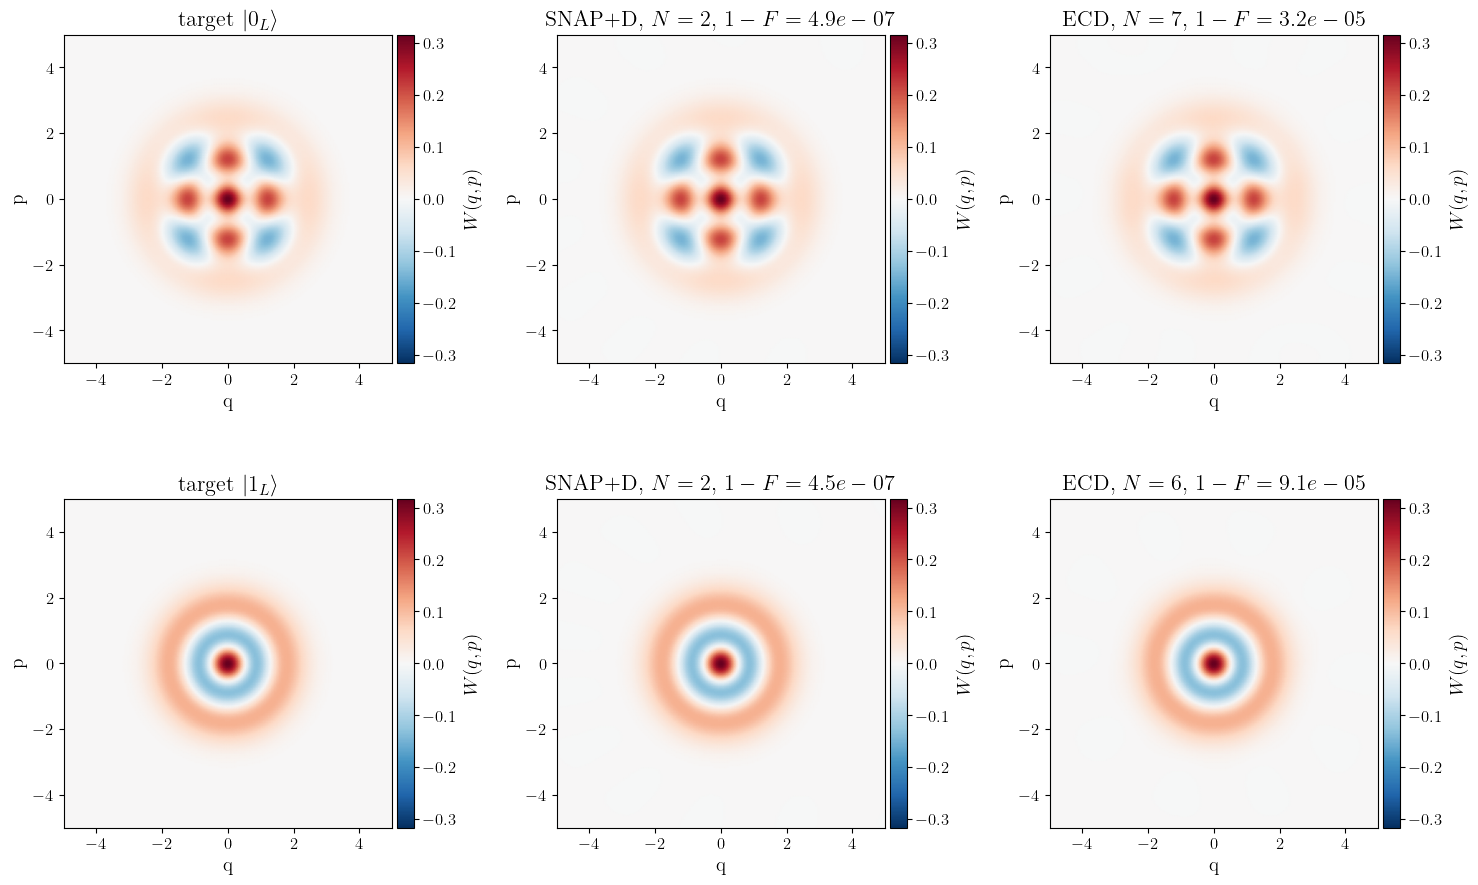

In [13]:
prep_tasks = ["prep_0", "prep_1"]
targets = {"prep_0": (bin_0, r"0_L"), "prep_1": (bin_1, r"1_L")}

fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))
for row, task in enumerate(prep_tasks):
    target, name = targets[task]
    plot_wigner(target, x_bound=5, y_bound=5, ax=axes[row][0],
                title=rf"target $\ket{{{name}}}$")
    for col, gate_set in enumerate(("snap", "ecd"), start=1):
        res = REFINED[(gate_set, task)]
        plot_wigner(
            res.final_qarray(), x_bound=5, y_bound=5, ax=axes[row][col],
            title=rf"{STYLE[gate_set]['label']}, $N={res.n_gates}$, "
                  rf"$1-F = {1 - res.fidelity:.1e}$",
        )
fig.tight_layout()
plt.show()

Photon-number distributions are the faster truncation check: the code words have support only on
$n \in \{0, 2, 4\}$, so any weight elsewhere is either infidelity or leakage, and weight near
$n = $ `N_FOCK` means `MAX_DISP` and `N_FOCK` are mismatched.

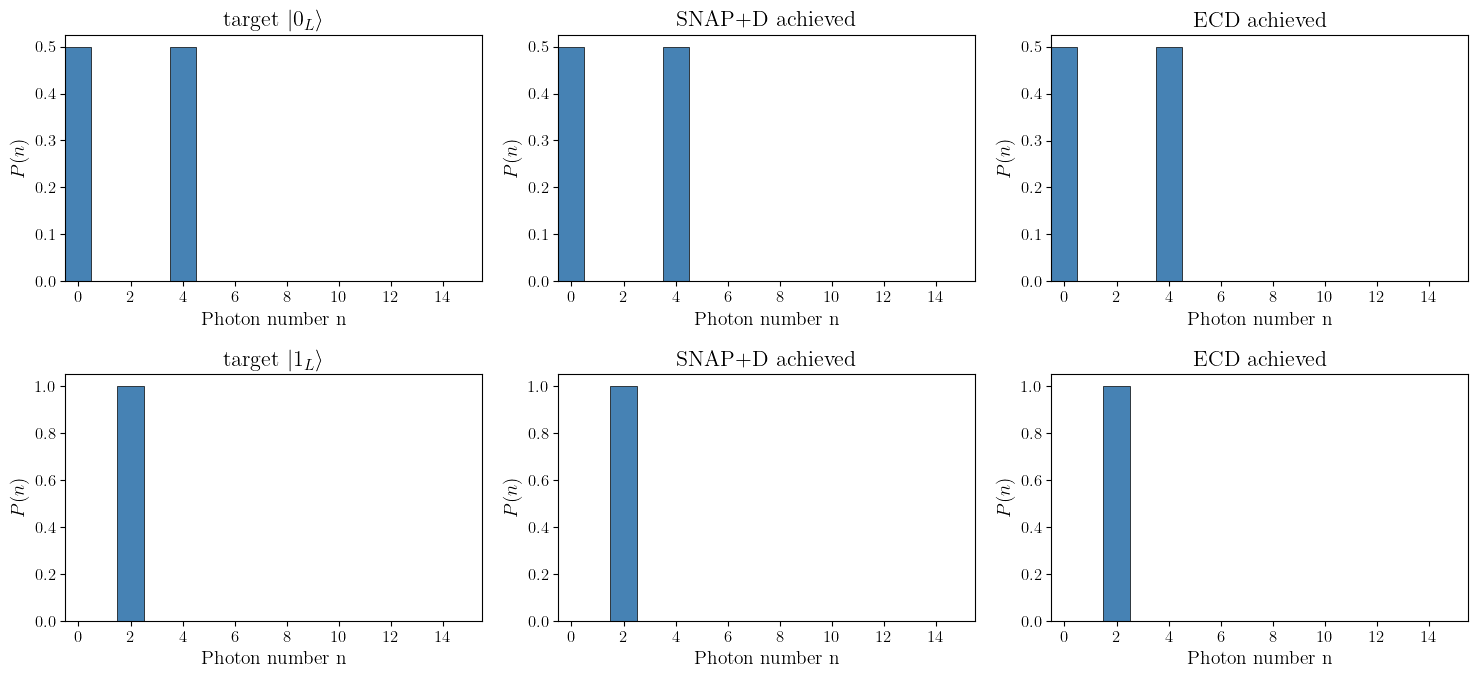

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for row, task in enumerate(prep_tasks):
    target, name = targets[task]
    plot_photon_number(target, ax=axes[row][0], max_n=16,
                       title=rf"target $\ket{{{name}}}$")
    for col, gate_set in enumerate(("snap", "ecd"), start=1):
        res = REFINED[(gate_set, task)]
        plot_photon_number(res.final_qarray(), ax=axes[row][col], max_n=16,
                           title=f"{STYLE[gate_set]['label']} achieved")
fig.tight_layout()
plt.show()

## The $X_L$ gate

Both code words under one parameter set. `per_pair_fidelity` is reported alongside the coherent
figure to expose the specific failure mode where each pair reaches its target individually but with
a relative phase error between them: high per-pair values with a visibly lower coherent $F$.

In [15]:
for gate_set in ("snap", "ecd"):
    res = REFINED[(gate_set, "X_L")]
    per_pair = np.asarray(res.params["per_pair_fidelity"])
    print(
        f"{gate_set:>4} | n_gates = {res.n_gates:>2} | coherent F = {res.fidelity:.6f} | "
        f"per-pair F = {np.round(per_pair, 6)} | "
        f"phase penalty = {per_pair.mean() - res.fidelity:+.2e}"
    )

snap | n_gates =  4 | coherent F = 0.999992 | per-pair F = [0.999992 0.999992] | phase penalty = +5.68e-12
 ecd | n_gates = 10 | coherent F = 0.988243 | per-pair F = [0.989429 0.987575] | phase penalty = +2.59e-04


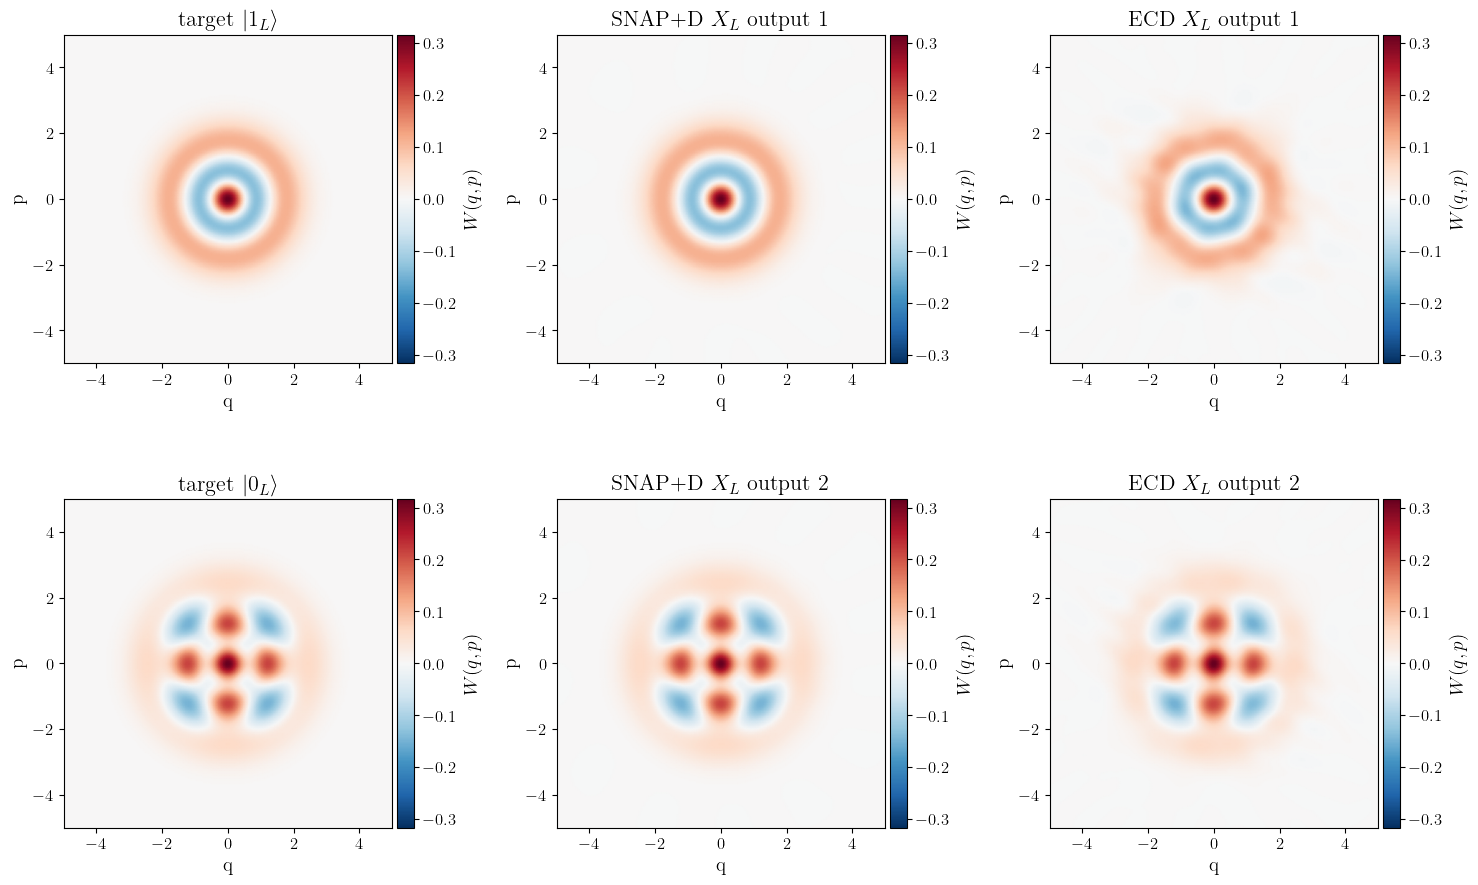

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))
x_targets = [(bin_1, r"1_L"), (bin_0, r"0_L")]
for row, (target, name) in enumerate(x_targets):
    plot_wigner(target, x_bound=5, y_bound=5, ax=axes[row][0],
                title=rf"target $\ket{{{name}}}$")
    for col, gate_set in enumerate(("snap", "ecd"), start=1):
        res = REFINED[(gate_set, "X_L")]
        finals = res.final_qarray()
        plot_wigner(
            finals[row], x_bound=5, y_bound=5, ax=axes[row][col],
            title=rf"{STYLE[gate_set]['label']} $X_L$ output {row + 1}",
        )
fig.tight_layout()
plt.show()

## Convergence diagnostics

For each refined circuit, the Adam trace over seeds and the final infidelity spread. The plotted
loss includes the leakage and displacement penalties, so it is not a pure $\log(1-F)$. Wide spread
means the multi-start is doing real work and more seeds would help; a tight spread at high
infidelity means the ansatz is the limitation.

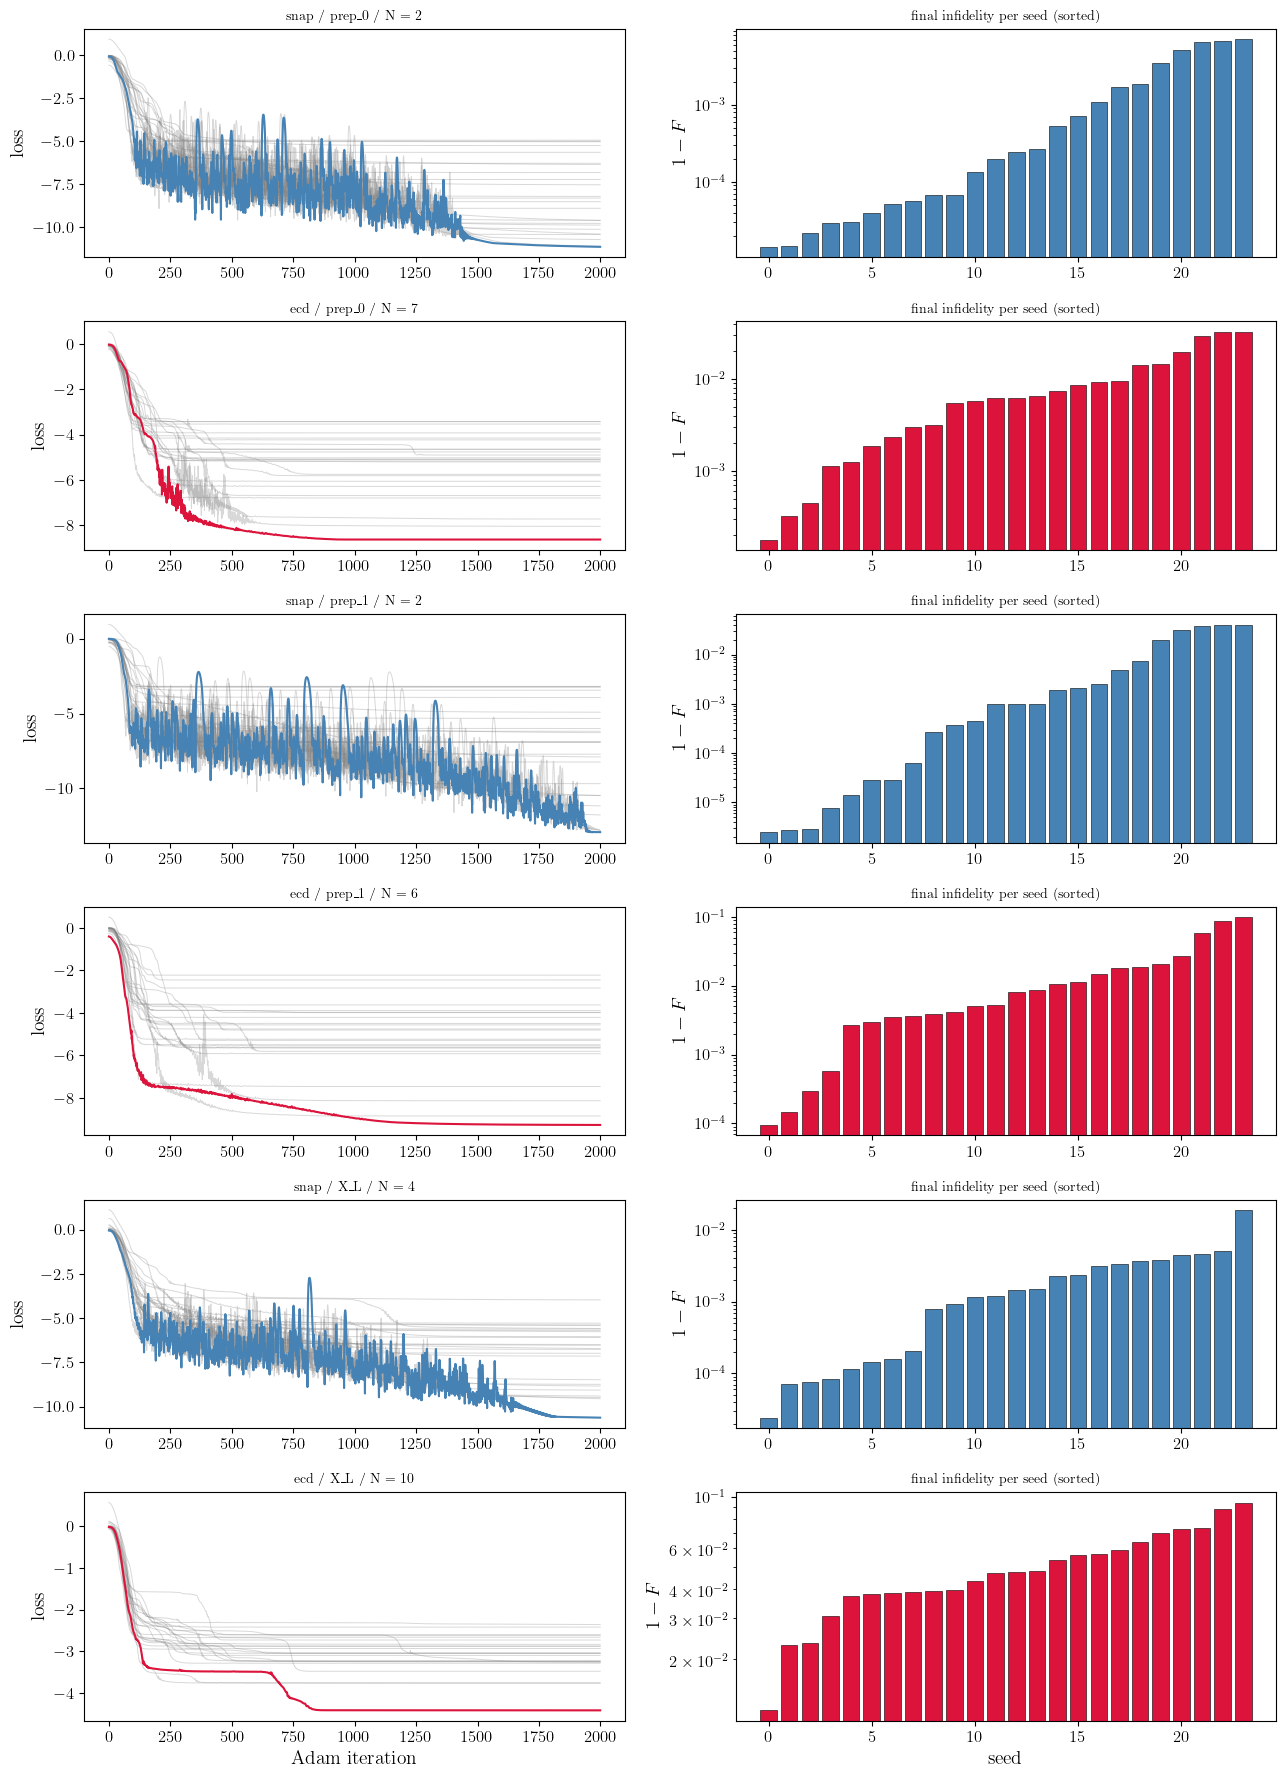

In [17]:
panels = [(gs, t) for t in TASKS for gs in ("snap", "ecd") if (gs, t) in RESULTS]

fig, axes = plt.subplots(len(panels), 2, figsize=(13, 3.0 * len(panels)))
axes = np.atleast_2d(axes)
for row, (gate_set, task) in enumerate(panels):
    d, res = best_result(gate_set, task)
    hist = np.asarray(res.adam_history)
    iters = np.arange(hist.shape[1])
    ax_h, ax_s = axes[row][0], axes[row][1]
    for k in range(hist.shape[0]):
        ax_h.plot(iters, hist[k], color="gray", alpha=0.3, linewidth=0.7)
    ax_h.plot(iters, hist[res.best_seed], color=STYLE[gate_set]["color"], linewidth=1.5)
    ax_h.set_ylabel("loss")
    ax_h.set_title(f"{gate_set} / {task} / N = {d}", fontsize=10)

    sorted_infid = 1 - np.sort(np.asarray(res.per_seed_fidelity))[::-1]
    ax_s.bar(np.arange(sorted_infid.size), sorted_infid,
             color=STYLE[gate_set]["color"], edgecolor="black", linewidth=0.4)
    ax_s.set_yscale("log")
    ax_s.set_ylabel(r"$1 - F$")
    ax_s.set_title("final infidelity per seed (sorted)", fontsize=10)
axes[-1][0].set_xlabel("Adam iteration")
axes[-1][1].set_xlabel("seed")
fig.tight_layout()
plt.show()

## Displacement amplitudes

The hardware-facing view of the solutions. For ECD the amplitude $|\beta_i|$ sets the conditional
displacement time and hence the ancilla-decoherence exposure of that layer; for SNAP it sets how far
the state leaves the low-Fock region where the selective pulses are valid. The dashed line is the
soft cap; the penalty is quadratic in the excess, so points sitting exactly on it mean the cap is
actively binding and the reported fidelity is a constrained optimum.

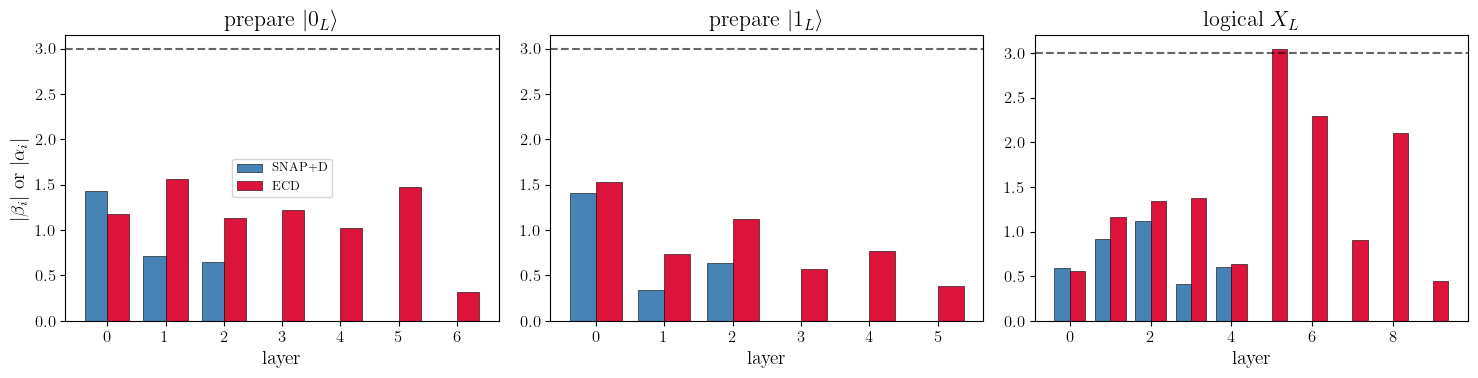

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
width = 0.38
for ax, (task, spec) in zip(axes, TASKS.items()):
    for k, gate_set in enumerate(("snap", "ecd")):
        if (gate_set, task) not in REFINED:
            continue
        mags = np.asarray(REFINED[(gate_set, task)].params["disp_magnitudes"])
        idx = np.arange(mags.size) + (k - 0.5) * width
        ax.bar(idx, mags, width=width, color=STYLE[gate_set]["color"],
               edgecolor="black", linewidth=0.4, label=STYLE[gate_set]["label"])
    ax.axhline(MAX_DISP, color="black", linestyle="--", alpha=0.6)
    ax.set_xlabel("layer")
    ax.set_title(spec["label"])
axes[0].set_ylabel(r"$|\beta_i|$ or $|\alpha_i|$")
axes[0].legend(fontsize=9)
fig.tight_layout()
plt.show()

## Optimal parameters

The deliverable: labelled parameters for each refined circuit. ECD gives rotation angles
$(\theta_i, \phi_i)$ and complex $\beta_i$; SNAP gives the phase table $\theta_{i,n}$ and complex
$\alpha_i$.

In [19]:
for (gate_set, task), res in REFINED.items():
    print("=" * 72)
    print(f"{gate_set.upper()} | {task} | n_gates = {res.n_gates} | "
          f"1 - F = {1 - res.fidelity:.3e}")
    p = res.params
    if gate_set == "ecd":
        print("thetas :", np.round(np.asarray(p["thetas"]), 4))
        print("phis   :", np.round(np.asarray(p["phis"]), 4))
        print("betas  :", [f"{b:+.4f}" for b in np.asarray(p["betas"])])
    else:
        print("alphas :", [f"{a:+.4f}" for a in np.asarray(p["alphas"])])
        print(f"snap phases (n_gates x {N_SNAP}):")
        print(np.round(np.asarray(p["snap_phases"]), 4))

SNAP | prep_0 | n_gates = 2 | 1 - F = 4.885e-07
alphas : ['-0.9843-1.0426j', '-0.0527-0.7127j', '-0.5718+0.3003j']
snap phases (n_gates x 12):
[[-4.6014 -0.7096  1.1885 -0.2454  1.7322  2.6236 -0.5866  2.2612 -0.9318
   2.2333 -0.7195  2.6978]
 [ 0.2649 -0.688  -0.6132 -1.7133 -0.2952  4.7549 -0.7446  0.1506 -5.0771
  -3.9224 -2.7438 -1.4747]]
ECD | prep_0 | n_gates = 7 | 1 - F = 3.232e-05
thetas : [1.5708 1.7461 1.9212 1.5065 0.6159 3.4054 1.5311 1.5708]
phis   : [-0.6222  2.193   0.9486  2.193   4.0902 -0.9486  0.9486  0.6222]
betas  : ['+0.9623+0.6777j', '+0.9049-1.2750j', '-1.0984+0.2750j', '+0.1753+1.2124j', '+0.8525+0.5648j', '-1.4048-0.4295j', '-0.1863+0.2502j']
SNAP | prep_1 | n_gates = 2 | 1 - F = 4.460e-07
alphas : ['-1.4013+0.1841j', '-0.0927+0.3237j', '-0.5758-0.2607j']
snap phases (n_gates x 12):
[[-2.2143  2.0943 -0.5991 -1.5775  1.6549 -0.6033  1.4774 -3.1594 -1.543
   0.0815  1.9577 -2.2702]
 [-1.3142  1.2048 -2.1214  2.9946  2.1957  2.5343  0.7784  0.6827 -1.672
  -1.7

The SNAP phase table is only meaningful modulo $2\pi$ and is unconstrained on Fock levels the state
never populates, so wrapping it before comparing two solutions avoids reading noise as structure.

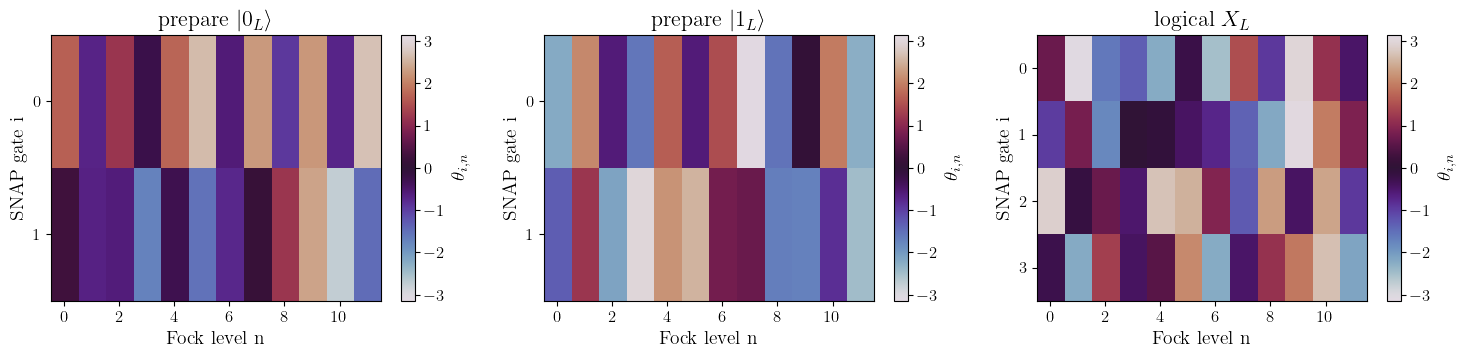

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, (task, spec) in zip(axes, TASKS.items()):
    res = REFINED[("snap", task)]
    phases = np.asarray(res.params["snap_phases"])
    wrapped = (phases + np.pi) % (2 * np.pi) - np.pi
    im = ax.imshow(wrapped, aspect="auto", cmap="twilight", vmin=-np.pi, vmax=np.pi)
    ax.set_xlabel("Fock level n")
    ax.set_ylabel("SNAP gate i")
    ax.set_yticks(np.arange(phases.shape[0]))
    ax.set_title(spec["label"])
    fig.colorbar(im, ax=ax, label=r"$\theta_{i,n}$")
fig.tight_layout()
plt.show()

## Export

Everything needed to reproduce or hand off a circuit: flat parameter vectors plus the run
configuration, in a single `.npz`. `flat_params` is what `params0` takes for a warm start, so a
saved run can be pushed further without repeating the sweep.

In [23]:
export = {
    "n_fock": N_FOCK,
    "n_snap": N_SNAP,
    "max_disp": MAX_DISP,
    "n_leak": N_LEAK,
    "target_f": TARGET_F,
    "code": "binomial S=1: (|0>+|4>)/sqrt(2), |2>",
}
for (gate_set, task), res in REFINED.items():
    tag = f"{gate_set}_{task}"
    export[f"{tag}__flat_params"] = np.asarray(res.flat_params)
    export[f"{tag}__n_gates"] = res.n_gates
    export[f"{tag}__fidelity"] = res.fidelity
    export[f"{tag}__leakage"] = res.leakage

# Full depth curves, for replotting without rerunning.
for (gate_set, task) in RESULTS:
    depths, infid, n_par = curve(gate_set, task)
    export[f"sweep_{gate_set}_{task}__depths"] = depths
    export[f"sweep_{gate_set}_{task}__infidelity"] = infid
    export[f"sweep_{gate_set}_{task}__n_params"] = n_par

out_path = "../../data/gate_optimization/binomial_codes/binomial_gate_opt_results.npz"
np.savez(out_path, **export)
print(f"wrote {out_path}  ({len(export)} arrays)")

wrote ../../data/gate_optimization/binomial_codes/binomial_gate_opt_results.npz  (48 arrays)


## Notes

Running log — fill in per run.

**Findings.**

- Minimum depths at $F_\star = 0.999$: SNAP `prep_0` / `prep_1` / `X_L` = _, _, _; ECD = _, _, _.
- Cheaper gate set by parameter count: _
- Was the displacement cap binding at the winning depths? _
- Did refinement move any depth across threshold (i.e. was the sweep budget the constraint)? _

**Open items.**

- Sweep `N_SNAP` — the $n \ge 12$ cutoff may be doing more work than the depth for this code, since
  the code words only occupy $n \le 4$.
- Sweep `MAX_DISP` to get an infidelity-vs-amplitude tradeoff curve; the current single cap
  conflates ansatz limits with the constraint.
- Repeat with `echoed=False` for the ECD set to check how much the echo is worth here.
- Higher members of the family ($S=2$, support to $\ket{6}$) to see how depth scales with code
  distance.
- Cross-check the winning ECD parameters against a pulse-level GRAPE run at matched duration; these
  are ideal-unitary numbers and the gap is the interesting quantity.